# Coral Bleaching Prediction — ConvLSTM (Early Stopping Version)
**Overfitting fix:** Early Stopping only (no dropout changes)

**Forecast:** 7 days ahead

**Train:** 2018–2023 | **Test:** 2024–2025

## Step 1: Upload Dataset

In [1]:
from google.colab import files
import zipfile, os

print("Click 'Choose Files' and select 3_dataset.zip ...")
uploaded = files.upload()

with zipfile.ZipFile('3_dataset.zip', 'r') as z:
    z.extractall('.')
print('Unzipped!')

DATASET_DIR = '/content/3_dataset'
SAVE_DIR    = '/content/4_models'
RESULTS_DIR = '/content/5_results'

os.makedirs(SAVE_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Dataset ready!')
print('Train files:', len(os.listdir(f'{DATASET_DIR}/train')))
print('Test files: ', len(os.listdir(f'{DATASET_DIR}/test')))

Click 'Choose Files' and select 3_dataset.zip ...


Saving 3_dataset.zip to 3_dataset.zip
Unzipped!
Dataset ready!
Train files: 1915
Test files:  727


## Step 2: Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


## Step 3: Dataset — 7-Day Forecast

In [3]:
FORECAST = 7

class CoralSequenceDataset(Dataset):
    def __init__(self, dataset_dir, labels_csv, seq_len=7):
        self.dataset_dir = dataset_dir
        self.seq_len     = seq_len

        df = pd.read_csv(labels_csv)
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)

        valid = []
        for _, row in df.iterrows():
            d    = row['date']
            path = f"{dataset_dir}/stacked_{d.year}_{d.month:02d}_{d.day:02d}.npy"
            if os.path.exists(path):
                valid.append({'date': d, 'label': int(row['label']), 'path': path})

        self.records = valid
        print(f'  Valid samples: {len(self.records)}')
        print(f'  Sequences available: {len(self)}')

    def __len__(self):
        return len(self.records) - self.seq_len - FORECAST + 1

    def __getitem__(self, idx):
        frames = []
        for i in range(self.seq_len):
            arr = np.load(self.records[idx + i]['path'])
            frames.append(arr)
        sequence = np.stack(frames, axis=0)
        label    = self.records[idx + self.seq_len - 1 + FORECAST]['label']
        return torch.tensor(sequence, dtype=torch.float32), torch.tensor(label, dtype=torch.long)


SEQ_LEN    = 7
BATCH_SIZE = 8

print('Loading train dataset...')
train_dataset = CoralSequenceDataset(
    f'{DATASET_DIR}/train',
    f'{DATASET_DIR}/train_labels.csv',
    seq_len=SEQ_LEN
)

print('\nLoading test dataset...')
test_dataset = CoralSequenceDataset(
    f'{DATASET_DIR}/test',
    f'{DATASET_DIR}/test_labels.csv',
    seq_len=SEQ_LEN
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

x, y = next(iter(train_loader))
print(f'\nBatch input shape: {x.shape}')
print(f'Batch label shape: {y.shape}')

Loading train dataset...
  Valid samples: 1915
  Sequences available: 1902

Loading test dataset...
  Valid samples: 727
  Sequences available: 714

Batch input shape: torch.Size([8, 7, 4, 224, 224])
Batch label shape: torch.Size([8])


## Step 4: Class Weights

In [4]:
all_labels = [train_dataset.records[i + SEQ_LEN - 1 + FORECAST]['label']
              for i in range(len(train_dataset))]

classes = np.array([0, 1, 2, 3, 4])
weights = compute_class_weight('balanced', classes=classes, y=all_labels)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print('Class weights:')
for i, w in enumerate(weights):
    print(f'  Class {i}: {w:.3f}')

Class weights:
  Class 0: 0.658
  Class 1: 0.865
  Class 2: 1.714
  Class 3: 1.838
  Class 4: 0.836


## Step 5: ConvLSTM Model (original dropout — no changes)

In [5]:
class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        padding = kernel_size // 2
        self.conv = nn.Conv2d(
            in_channels + hidden_channels,
            4 * hidden_channels,
            kernel_size=kernel_size,
            padding=padding
        )

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        gates    = self.conv(combined)
        i, f, g, o = gates.chunk(4, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        g = torch.tanh(g)
        o = torch.sigmoid(o)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next


class CoralConvLSTM(nn.Module):
    def __init__(self, in_channels=4, hidden_channels=32, num_classes=5):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.convlstm = ConvLSTMCell(
            in_channels=hidden_channels,
            hidden_channels=hidden_channels,
            kernel_size=3
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(hidden_channels * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.4),          # original dropout
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        batch, seq_len, C, H, W = x.shape
        encoded = []
        for t in range(seq_len):
            enc = self.encoder(x[:, t])
            encoded.append(enc)
        _, hidden_ch, Hd, Wd = encoded[0].shape
        h = torch.zeros(batch, hidden_ch, Hd, Wd).to(x.device)
        c = torch.zeros(batch, hidden_ch, Hd, Wd).to(x.device)
        for t in range(seq_len):
            h, c = self.convlstm(encoded[t], h, c)
        return self.classifier(h)


model = CoralConvLSTM(
    in_channels=4,
    hidden_channels=32,
    num_classes=5
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')

Total trainable parameters: 154,645


## Step 6: Early Stopping Class

In [6]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience    = patience
        self.min_delta   = min_delta
        self.counter     = 0
        self.best_acc    = 0.0
        self.should_stop = False

    def check(self, val_acc):
        if val_acc > self.best_acc + self.min_delta:
            self.best_acc = val_acc
            self.counter  = 0
        else:
            self.counter += 1
            print(f'  No improvement {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.should_stop = True

## Step 7: Training Setup

In [7]:
EPOCHS = 30
LR     = 1e-3

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
print(f'Training for {EPOCHS} epochs on {device}')

Training for 30 epochs on cuda


## Step 8: Train (Early Stopping only — NO dropout changes)

In [8]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out  = model(X)
            loss = criterion(out, y)
            total_loss += loss.item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total


best_val_acc  = 0.0
early_stopping = EarlyStopping(patience=5)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = eval_epoch(model,  test_loader,  criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'{SAVE_DIR}/convlstm_earlystop_best.pth')

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}'
          + (' <- best saved' if val_acc == best_val_acc else ''))

    early_stopping.check(val_acc)
    if early_stopping.should_stop:
        print(f'\n Early stopping triggered at epoch {epoch}!')
        break

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Epoch 01/30 | Train Loss: 1.2757  Acc: 0.5216 | Val Loss: 0.7767  Acc: 0.6709 <- best saved
Epoch 02/30 | Train Loss: 0.8882  Acc: 0.6809 | Val Loss: 0.7873  Acc: 0.6779 <- best saved
Epoch 03/30 | Train Loss: 0.7527  Acc: 0.7177 | Val Loss: 0.7699  Acc: 0.6989 <- best saved
Epoch 04/30 | Train Loss: 0.6444  Acc: 0.7613 | Val Loss: 0.8884  Acc: 0.6555
  No improvement 1/5
Epoch 05/30 | Train Loss: 0.6065  Acc: 0.7687 | Val Loss: 0.9417  Acc: 0.6863
  No improvement 2/5
Epoch 06/30 | Train Loss: 0.5156  Acc: 0.8002 | Val Loss: 0.7493  Acc: 0.7297 <- best saved
Epoch 07/30 | Train Loss: 0.5123  Acc: 0.8113 | Val Loss: 1.0446  Acc: 0.6835
  No improvement 1/5
Epoch 08/30 | Train Loss: 0.4830  Acc: 0.8091 | Val Loss: 0.9150  Acc: 0.7241
  No improvement 2/5
Epoch 09/30 | Train Loss: 0.4323  Acc: 0.8381 | Val Loss: 1.0696  Acc: 0.6723
  No improvement 3/5
Epoch 10/30 | Train Loss: 0.4204  Acc: 0.8486 | Val Loss: 1.1835  Acc: 0.6653
  No improvement 4/5
Epoch 11/30 | Train Loss: 0.3358  Acc:

## Step 9: Plot Training History

Epochs trained: 11


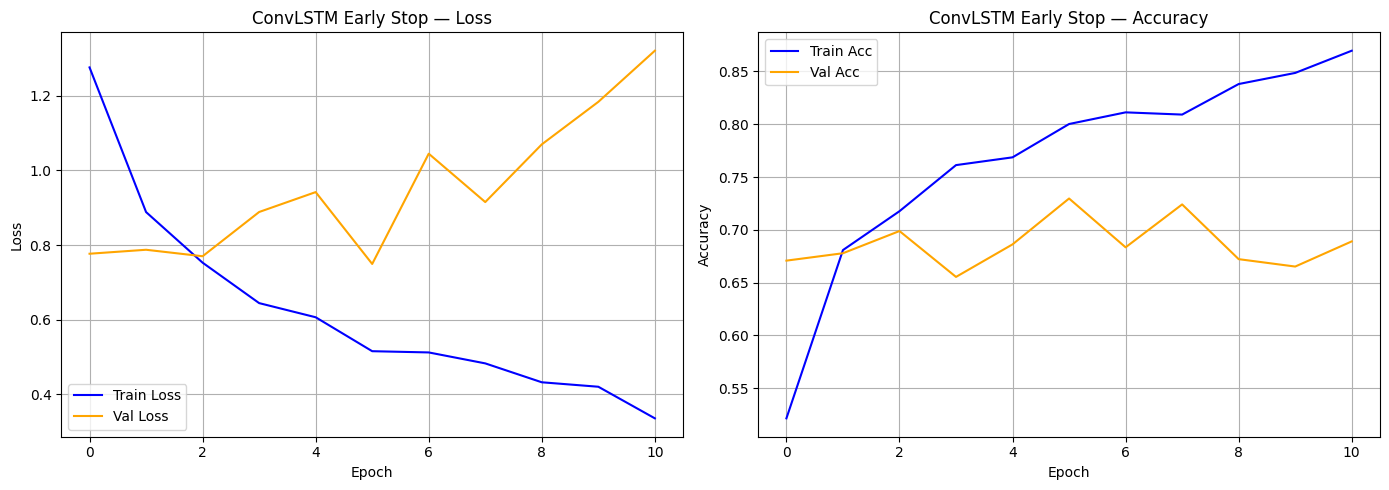

Saved training plot!


In [9]:
actual_epochs = len(history['train_loss'])
print(f'Epochs trained: {actual_epochs}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='orange')
axes[0].set_title('ConvLSTM Early Stop — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train Acc', color='blue')
axes[1].plot(history['val_acc'],   label='Val Acc',   color='orange')
axes[1].set_title('ConvLSTM Early Stop — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/convlstm_earlystop_training.png', dpi=150)
plt.show()
print('Saved training plot!')

## Step 10: Evaluate on Test Set

In [10]:
model.load_state_dict(torch.load(f'{SAVE_DIR}/convlstm_earlystop_best.pth'))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for X, y in test_loader:
        X     = X.to(device)
        out   = model(X)
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds, average='weighted')

print('='*50)
print('ConvLSTM EARLY STOPPING — TEST RESULTS')
print('='*50)
print(f'Accuracy:          {acc:.4f}')
print(f'Weighted F1 Score: {f1:.4f}')
print()
print(classification_report(
    all_labels, all_preds,
    target_names=['No Stress', 'Watch', 'Warning', 'Alert L1', 'Alert L2']
))

ConvLSTM EARLY STOPPING — TEST RESULTS
Accuracy:          0.7297
Weighted F1 Score: 0.7085

              precision    recall  f1-score   support

   No Stress       0.77      0.74      0.76       125
       Watch       0.80      0.50      0.61       237
     Warning       0.52      1.00      0.69        46
    Alert L1       0.67      0.22      0.33        46
    Alert L2       0.74      0.98      0.84       260

    accuracy                           0.73       714
   macro avg       0.70      0.69      0.65       714
weighted avg       0.75      0.73      0.71       714



## Step 11: Confusion Matrix

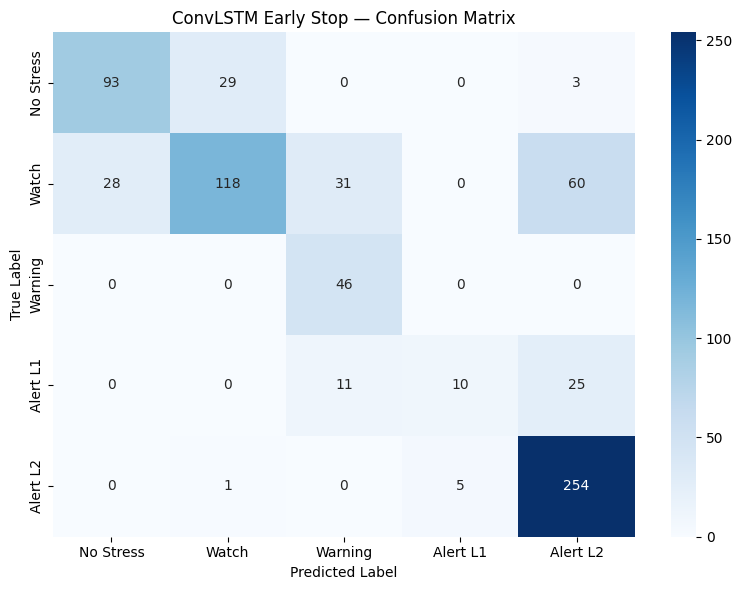

In [12]:
cm     = confusion_matrix(all_labels, all_preds)
labels = ['No Stress', 'Watch', 'Warning', 'Alert L1', 'Alert L2']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('ConvLSTM Early Stop — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/convlstm_earlystop_confusion.png', dpi=150)
plt.show()

## Step 12: Save & Download Results

In [13]:
import json

results = {
    'model':         'ConvLSTM Early Stopping',
    'accuracy':      round(float(acc), 4),
    'f1_weighted':   round(float(f1), 4),
    'best_val_acc':  round(float(best_val_acc), 4),
    'epochs':        actual_epochs,
    'forecast_days': FORECAST,
    'fix':           'early stopping only'
}

with open(f'{RESULTS_DIR}/convlstm_earlystop_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))

from google.colab import files
files.download(f'{SAVE_DIR}/convlstm_earlystop_best.pth')
files.download(f'{RESULTS_DIR}/convlstm_earlystop_results.json')
files.download(f'{RESULTS_DIR}/convlstm_earlystop_training.png')
files.download(f'{RESULTS_DIR}/convlstm_earlystop_confusion.png')
print('Downloaded!')

{
  "model": "ConvLSTM Early Stopping",
  "accuracy": 0.7297,
  "f1_weighted": 0.7085,
  "best_val_acc": 0.7297,
  "epochs": 11,
  "forecast_days": 7,
  "fix": "early stopping only"
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded!
